In [0]:

from google.colab import drive

drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


import zipfile
from google.colab import drive

drive.mount('/content/drive/')


zip_ref = zipfile.ZipFile("/content/drive/My Drive/Colab Notebooks/catsdogsds.zip", 'r')
zip_ref.extractall("/sample_data")
zip_ref.close()

In [0]:
import zipfile 


zip_ref = zipfile.ZipFile("/content/drive/My Drive/Colab Notebooks/catsdogsds.zip", 'r') 
zip_ref.extractall("/sample_data") 
zip_ref.close()

In [0]:

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras
from keras import layers,models,optimizers
from keras.preprocessing.image import ImageDataGenerator,image


# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
import os ,shutil





print(tf.__version__)

2.2.0


Using TensorFlow backend.


In [0]:
#base_dir='/Users/magadi.sudhindra/AIML_Dataset/trainds'
train_base_dir='/sample_data/catsdogsds/train'
validation_base_dir='/sample_data/catsdogsds/validation'
test_base_dir='/sample_data/catsdogsds/test'

train_cats_dir=os.path.join(train_base_dir,'cats')
train_dogs_dir=os.path.join(train_base_dir,'dogs')

validation_cats_dir=os.path.join(validation_base_dir,'cats')
validation_dogs_dir=os.path.join(validation_base_dir,'dogs')

test_cats_dir=os.path.join(test_base_dir,'cats')
test_dogs_dir=os.path.join(test_base_dir,'dogs')

In [0]:
print('Cat Training:',len(os.listdir(train_cats_dir)))
print('Cat Testing:',len(os.listdir(test_cats_dir)))
print('Cat Val:',len(os.listdir(validation_cats_dir)))
print('Dog Training:',len(os.listdir(train_dogs_dir)))
print('Dog Testing:',len(os.listdir(test_dogs_dir)))
print('Dog Val:',len(os.listdir(validation_dogs_dir)))

Cat Training: 7000
Cat Testing: 2499
Cat Val: 2999
Dog Training: 7000
Dog Testing: 2499
Dog Val: 2999


In [0]:
basemodel=models.Sequential()
basemodel.add(layers.Conv2D(32,(3,3),activation='relu',
                            input_shape=(150,150,3)))
basemodel.add(layers.MaxPooling2D(2,2))
basemodel.add(layers.Conv2D(64,(3,3),activation='relu'))
basemodel.add(layers.MaxPooling2D(2,2))
basemodel.add(layers.Conv2D(128,(3,3),activation='relu'))
basemodel.add(layers.MaxPooling2D(2,2))
basemodel.add(layers.Conv2D(128,(3,3),activation='relu'))
basemodel.add(layers.MaxPooling2D(2,2))
basemodel.add(layers.Flatten())
basemodel.add(layers.Dense(512,activation='relu'))
basemodel.add(layers.Dense(1,activation='sigmoid'))

basemodel.summary()



Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_5 (Conv2D)            (None, 148, 148, 32)      896       
_________________________________________________________________
max_pooling2d_5 (MaxPooling2 (None, 74, 74, 32)        0         
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 72, 72, 64)        18496     
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (None, 36, 36, 64)        0         
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 34, 34, 128)       73856     
_________________________________________________________________
max_pooling2d_7 (MaxPooling2 (None, 17, 17, 128)       0         
_________________________________________________________________
conv2d_8 (Conv2D)            (None, 15, 15, 128)      

In [0]:
basemodel.compile(loss='binary_crossentropy',
                  optimizer=optimizers.RMSprop(lr=1e-4),
                  metrics=['acc'])

In [0]:
train_datagen = ImageDataGenerator( rescale=1./255)
test_datagen = ImageDataGenerator( rescale=1./255)

In [0]:
train_gen = train_datagen.flow_from_directory(train_base_dir,
                                              target_size=(150,150),
                                              batch_size=20,
                                              class_mode='binary')

Found 14000 images belonging to 2 classes.


In [0]:
valid_gen = test_datagen.flow_from_directory(validation_base_dir,
                                              target_size=(150,150),
                                              batch_size=20,
                                              class_mode='binary')

Found 5998 images belonging to 2 classes.


In [0]:
for data_batch,labels_batch in train_gen:
  print('data batch size ',data_batch.shape)
  print('labels batch size ',labels_batch.shape)
  break

data batch size  (20, 150, 150, 3)
labels batch size  (20,)


In [0]:
history=basemodel.fit_generator(train_gen,
                                steps_per_epoch=100,
                                epochs=30,
                                validation_data=valid_gen,
                                validation_steps=50)
    



Epoch 1/30
100/100 [==============================] - 9s 93ms/step - loss: 0.6901 - acc: 0.5220 - val_loss: 0.6832 - val_acc: 0.5740
Epoch 2/30
100/100 [==============================] - 8s 82ms/step - loss: 0.6753 - acc: 0.5800 - val_loss: 0.5813 - val_acc: 0.5500
Epoch 3/30
100/100 [==============================] - 8s 83ms/step - loss: 0.6473 - acc: 0.6235 - val_loss: 0.6685 - val_acc: 0.5820
Epoch 4/30
100/100 [==============================] - 8s 82ms/step - loss: 0.6221 - acc: 0.6570 - val_loss: 0.6514 - val_acc: 0.5830
Epoch 5/30
100/100 [==============================] - 8s 82ms/step - loss: 0.5863 - acc: 0.6935 - val_loss: 0.5324 - val_acc: 0.6640
Epoch 6/30
100/100 [==============================] - 8s 82ms/step - loss: 0.5634 - acc: 0.7110 - val_loss: 0.5779 - val_acc: 0.6954
Epoch 7/30
100/100 [==============================] - 8s 84ms/step - loss: 0.5562 - acc: 0.7075 - val_loss: 0.6285 - val_acc: 0.7180
Epoch 8/30
100/100 [==============================] - 8s 83ms/step - 

In [0]:
basemodel.save('basemodel_cats_and_dogs_17May2020.h5')

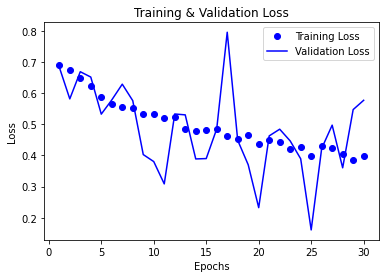

In [0]:
history_dict=history.history
history_dict.keys()
loss_values=history_dict['loss']
val_loss_values=history_dict['val_loss']
epochs= range(1,len(loss_values)+1)
plt.plot(epochs,loss_values,'bo',label='Training Loss')
plt.plot(epochs,val_loss_values,'b',label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [0]:
history_dict=history.history
history_dict.keys()

dict_keys(['val_loss', 'val_acc', 'loss', 'acc'])

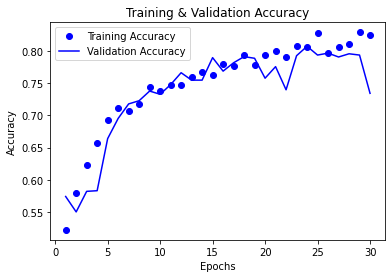

In [0]:
plt.clf()

acc=history_dict['acc']
val_acc=history_dict['val_acc']

plt.plot(epochs,acc,'bo',label='Training Accuracy')
plt.plot(epochs,val_acc,'b',label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [0]:
dataaugmentedmodel=models.Sequential()
dataaugmentedmodel.add(layers.Conv2D(32,(3,3),activation='relu',
                            input_shape=(150,150,3)))
dataaugmentedmodel.add(layers.MaxPooling2D(2,2))
dataaugmentedmodel.add(layers.Conv2D(64,(3,3),activation='relu'))
dataaugmentedmodel.add(layers.MaxPooling2D(2,2))
dataaugmentedmodel.add(layers.Conv2D(128,(3,3),activation='relu'))
dataaugmentedmodel.add(layers.MaxPooling2D(2,2))
dataaugmentedmodel.add(layers.Conv2D(128,(3,3),activation='relu'))
dataaugmentedmodel.add(layers.MaxPooling2D(2,2))
dataaugmentedmodel.add(layers.Flatten())
#dataaugmentedmodel.add(layers.Dropout(0.5))
dataaugmentedmodel.add(layers.Dense(512,activation='relu'))
dataaugmentedmodel.add(layers.Dense(1,activation='sigmoid'))

dataaugmentedmodel.summary()


Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 148, 148, 32)      896       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 74, 74, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 72, 72, 64)        18496     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 36, 36, 64)        0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 34, 34, 128)       73856     
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 17, 17, 128)       0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 15, 15, 128)      

In [0]:
dataaugmentedmodel.compile(loss='binary_crossentropy',
                  optimizer=optimizers.RMSprop(),
                  metrics=['acc'])

In [0]:
#Train using DataAugmented Generators

In [0]:
train_datagen = ImageDataGenerator( rescale=1./255,
                                   rotation_range=40,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True
                                   )


In [0]:
train_gen = train_datagen.flow_from_directory(train_base_dir,
                                              target_size=(150,150),
                                              batch_size=32,
                                              class_mode='binary')

Found 14000 images belonging to 2 classes.


In [0]:
test_datagen = ImageDataGenerator( rescale=1./255)
valid_gen = test_datagen.flow_from_directory(validation_base_dir,
                                              target_size=(150,150),
                                              batch_size=32,
                                              class_mode='binary')

Found 5998 images belonging to 2 classes.


In [0]:
history=dataaugmentedmodel.fit_generator(train_gen,
                                steps_per_epoch=100,
                                epochs=30,
                                validation_data=valid_gen,
                                validation_steps=50)

Epoch 1/30
100/100 [==============================] - 38s 375ms/step - loss: 0.7385 - acc: 0.5028 - val_loss: 0.6932 - val_acc: 0.5113
Epoch 2/30
100/100 [==============================] - 31s 310ms/step - loss: 0.6925 - acc: 0.5556 - val_loss: 0.6481 - val_acc: 0.6037
Epoch 3/30
100/100 [==============================] - 31s 307ms/step - loss: 0.6870 - acc: 0.5672 - val_loss: 0.7333 - val_acc: 0.5856
Epoch 4/30
100/100 [==============================] - 31s 312ms/step - loss: 0.6741 - acc: 0.6178 - val_loss: 0.7329 - val_acc: 0.6245
Epoch 5/30
100/100 [==============================] - 31s 309ms/step - loss: 0.6582 - acc: 0.6209 - val_loss: 0.5930 - val_acc: 0.6081
Epoch 6/30
100/100 [==============================] - 31s 308ms/step - loss: 0.6502 - acc: 0.6288 - val_loss: 0.6254 - val_acc: 0.6294
Epoch 7/30
100/100 [==============================] - 31s 306ms/step - loss: 0.6325 - acc: 0.6467 - val_loss: 0.6257 - val_acc: 0.6913
Epoch 8/30
100/100 [==============================] - 3